In [1]:
import pandas as pd

# Load datasets
red = pd.read_csv("data/winequality-red.csv", sep=';')
white = pd.read_csv("data/winequality-white.csv", sep=';')

# Add new column to identify type
red['type'] = 'red'
white['type'] = 'white'

# Combine datasets
data = pd.concat([red, white], ignore_index=True)

# Check result
print(data.head())
print(data.shape)
print(data['type'].value_counts())

# Save combined dataset
data.to_csv("data/winequality_combined.csv", index=False)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8        5  red  
2    

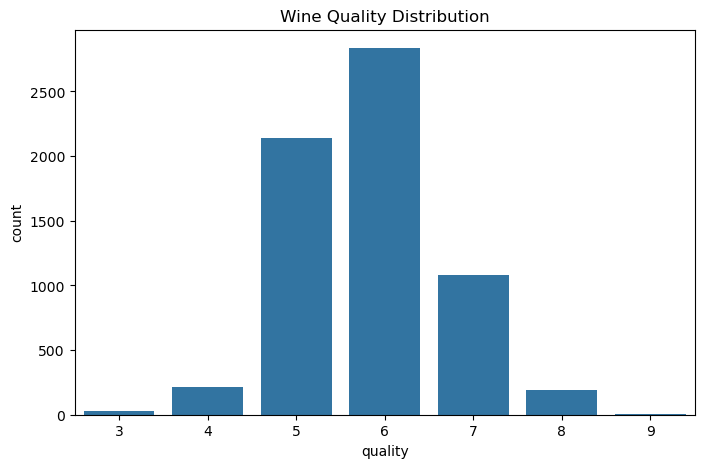

In [2]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize quality distribution
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data)
plt.title("Wine Quality Distribution")
plt.show()


In [3]:
# Create quality labels
def quality_label(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

data['quality_label'] = data['quality'].apply(quality_label)

print(data[['quality', 'quality_label']].head())
print(data['quality_label'].value_counts())

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['quality_encoded'] = le.fit_transform(data['quality_label'])

print(data[['quality_label', 'quality_encoded']].head())

# Encode 'type' column
data = pd.get_dummies(data, columns=['type'], drop_first=True)


   quality quality_label
0        5        Medium
1        5        Medium
2        5        Medium
3        6        Medium
4        5        Medium
quality_label
Medium    4974
High      1277
Low        246
Name: count, dtype: int64
  quality_label  quality_encoded
0        Medium                2
1        Medium                2
2        Medium                2
3        Medium                2
4        Medium                2


In [4]:
# Split features and target

X = data.drop(['quality', 'quality_label', 'quality_encoded'], axis=1)
y = data['quality_encoded']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.40      0.79      0.53       256
           1       0.12      0.63      0.19        49
           2       0.89      0.48      0.62       995

    accuracy                           0.54      1300
   macro avg       0.47      0.63      0.45      1300
weighted avg       0.76      0.54      0.59      1300

Confusion Matrix:


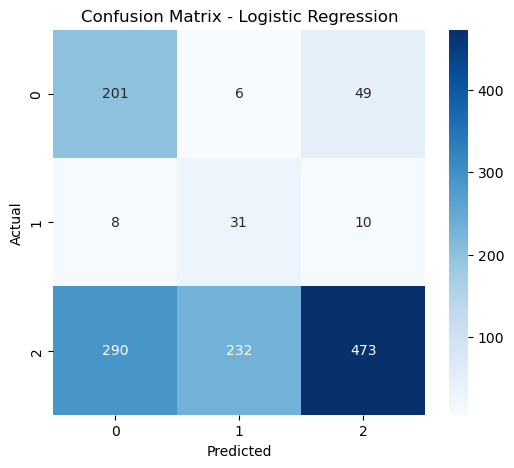

In [5]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.54      0.65       256
           1       1.00      0.12      0.22        49
           2       0.86      0.97      0.91       995

    accuracy                           0.85      1300
   macro avg       0.89      0.54      0.59      1300
weighted avg       0.86      0.85      0.83      1300

Confusion Matrix:


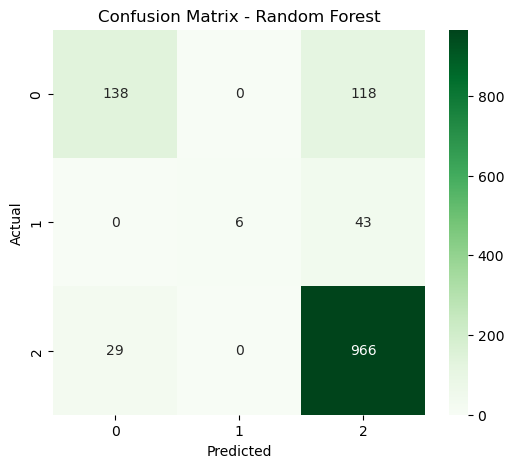

In [6]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# Using class_weight='balanced' to handle class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
corr = data.corr(numeric_only=True)['quality'].sort_values(ascending=False)
print(corr)

quality                 1.000000
alcohol                 0.444319
type_white              0.119323
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
quality_encoded        -0.650079
Name: quality, dtype: float64
